In [2]:
from erddapy import ERDDAP
import pandas as pd
import os
import requests
from accessibility import check_endpoint
from summarize import * #json_keys, data_frame

### Interoperability Assessment of EMSO ERDDAP server

### Endpoint

In [2]:
endpoint = "https://erddap.emso.eu/erddap"

##### Table Of Content

- [Exploring the ERDDAP server](#exploring-the-erddap-server)
- [Technical interoperability](#technical-interoperability)
    - [Protocol support](#protocol-support)
    - [Data format compatibility](#data-format-compatibility) 
    - [Discovery capabilities](#discovery-capabilities) 
- [Semantic interoperability](#semantic-interoperability)
    - [Presence and richness of metadata](#presence-and-richness-of-metadata)
    - [Use of standard vocabularies](#use-of-standard-vocablaries)  
    - [Data annotations completeness](#data-annotations-completeness)

In [ ]:
#make connection
e = ERDDAP( server=endpoint, 
            protocol="tabledap")

### Exploring the ERDDAP server
Exploration of available metadata of datasets, available through the ERDDAP server

In [ ]:
# (note:endpoint also assessed via browser)
# e.g. server metadata:
    # https://erddap.emso.eu/erddap/status.html --> available, info on number of datasets, failing datasets, duplicates, users, etc.
    # https://erddap.emso.eu/erddap/version.html --> not available 
    # https://erddap.emso.eu/erddap/tabledap/documentation.html --> documentation, info on supported download formats, etc. (many download formats available, e.g. CSV, JSON, NetCDF, ...!!)

Exploration of "allDatasets" dataset:  
_This dataset serves as a catalog of all datasets available on the ERDDAP server, returning a DataFrame with essential metadata to identify and filter datasets of interest._

In [ ]:
e.dataset_id = "allDatasets" # "allDatasets" is a dataset that lists all available datasets on the ERDDAP server, together with metadata that allows you to identify and filter the datasets of interest  
alldatasets_df = e.to_pandas()
print(f"ERDDAP server offers {len(alldatasets_df['datasetID'].drop_duplicates())} datasets.")
alldatasets_df

For each dataset in the ERDDAP server, retrieve metadata about variables, attributes, and data types, including example attribute values and dimension information. And combine this metadata from all datasets into one DataFrame.

In [ ]:
metadatainfo_df = pd.DataFrame(columns=["Row Type", "Variable Name", "Attribute Name", "Data Type", "Value", "DatasetID"])
# get metadata information for each dataset
for datasetID in alldatasets_df['datasetID']:
    e.dataset_id = datasetID
    try:
        _df = pd.read_csv(e.get_info_url(response="csv")) #metadata retrieved via info_url
        _df["DatasetID"] = datasetID
        metadatainfo_df = pd.concat([metadatainfo_df, _df], ignore_index=True)
    except Exception as e:
        print(f"there was an error for {datasetID}: '{e}'")
        continue

# save to csv file
os.mkdir("files_emso_erddap") if not os.path.exists("files_emso_erddap") else None
metadatainfo_df.to_csv("files_emso_erddap/all_dataset_metadata.csv", index=False)
metadatainfo_df

In [ ]:
# explore returned metadata
metadatainfo_df.groupby(['DatasetID', 'Row Type']).nunique()

In [ ]:
# Explore the dimensions of each dataset (Row Type = 'dimension')
dim_info = metadatainfo_df[ metadatainfo_df['Row Type'] == 'dimension'].groupby(['DatasetID', 'Variable Name']).agg({
        'Data Type': 'unique',
        'Value': 'unique'
    }).reset_index()
dim_info.to_csv("files_emso_erddap/dataset_metadata_dimensions.csv", index=False)
dim_info

In [ ]:
# Explore the variables of each dataset (Row Type = 'variable')
#note: in netCDFs, attributes represent additional information 
var_info = metadatainfo_df[ metadatainfo_df['Row Type'] == 'variable'].groupby(['DatasetID', 'Variable Name']).agg({
        'Data Type': 'unique',
        'Value': 'unique'
    }).reset_index()
var_info.to_csv("files_emso_erddap/dataset__metadata_variables.csv", index=False)
var_info

In [ ]:
# Explore the attributes of each dataset (Row Type = 'attribute')
metadatainfo_df[ metadatainfo_df['Row Type'] == 'attribute'].groupby(['DatasetID', 'Attribute Name']).nunique()

In [ ]:
# and the variables/dimensions with which they're associated 
attr_info = metadatainfo_df[ metadatainfo_df['Row Type'] == 'attribute'].groupby(['DatasetID', 'Attribute Name', 'Variable Name']).agg({
        'Data Type': 'unique',
        'Value': 'unique'
    }).reset_index()
attr_info.to_csv("files_emso_erddap/dataset_metadata_attributes.csv", index=False)
attr_info

##### Exploration of some example datasets

In [3]:
# Example dataset
DATASET_ID = "EMSO_OBSEA_Buoy_Airmar_150WX_30min"

In [ ]:
# Data Descriptor Service
DDS_URL = f"{endpoint}/tabledap/{DATASET_ID}.dds"
print("DDS URL: ",DDS_URL)
dds_text = requests.get(DDS_URL).text
print(dds_text)

In [ ]:
# Data Access Service
DAS_URL = f"{endpoint}/tabledap/{DATASET_ID}.das"
print("DAS URL", DAS_URL)
das_text = requests.get(DAS_URL).text
print(das_text)

In [4]:
# Metadata summary
INFO_URL = f"{endpoint}/info/{DATASET_ID}/index.json" 
print("INFO URL", INFO_URL)
info_json = requests.get(INFO_URL).json()
info_json

INFO URL https://erddap.emso.eu/erddap/info/EMSO_OBSEA_Buoy_Airmar_150WX_30min/index.json


NameError: name 'requests' is not defined

In [ ]:
#Get data (as 2D dataframe)
e.dataset_id = DATASET_ID

EMSO_OBSEA_Buoy_Airmar_150WX_30min_df = e.to_pandas()
EMSO_OBSEA_Buoy_Airmar_150WX_30min_df

In [ ]:
#Get data (as ncCF)
EMSO_OBSEA_Buoy_Airmar_150WX_30min_nc = e.to_ncCF()
EMSO_OBSEA_Buoy_Airmar_150WX_30min_nc

In [ ]:
# Another example dataset
DATASET_ID = "EMSO_OBSEA_CTD_30min"

In [ ]:
# Data Descriptor Service
DDS_URL = f"{endpoint}/tabledap/{DATASET_ID}.dds"
print("DDS URL: ",DDS_URL)
dds_text = requests.get(DDS_URL).text
print(dds_text)

In [ ]:
# Data Access Service
DAS_URL = f"{endpoint}/tabledap/{DATASET_ID}.das"
print("DAS URL", DAS_URL)
das_text = requests.get(DAS_URL).text
print(das_text)

In [ ]:
# Metadata summary
INFO_URL = f"{endpoint}/info/{DATASET_ID}/index.json"
print("INFO URL", INFO_URL)
info_json = requests.get(INFO_URL).json()
info_json

In [ ]:
#Get data (as 2D dataframe)
e.dataset_id = DATASET_ID

EMSO_OBSEA_CTD_30min_df = e.to_pandas()
EMSO_OBSEA_CTD_30min_df

In [ ]:
#Get data (as ncCF)
EMSO_OBSEA_CTD_30min_nc = e.to_ncCF()
EMSO_OBSEA_CTD_30min_nc

### Technical interoperability

#### Protocol support  
*Involves checking whether standard data access protocols are supported*

In [ ]:
if check_endpoint(endpoint):
    print("The endpoint is machine-accessible.")
else:
    print("The endpoint is not machine-accessible.")

In [ ]:
response = requests.get(endpoint)
server_headers = response.headers

tech_results = {
    # General protocol and status checks
    "General protocol and status checks" : 
        {
        "HTTP/HTTPS Protocol": endpoint.startswith("http"),
        "Status Code 200 OK": response.status_code == 200,
        },
    # Content negotiation
    "Content negotiation" : 
        {
        "MIME Type Present": "Content-Type" in server_headers,
        "MIME Type": server_headers.get("Content-Type"),
        "Content Negotiation Support": "Vary" in server_headers or "Accept" in server_headers,
        "Vary": server_headers.get("Vary"),                         # response may change depending on 'Accept-Encoding'
        "Accept-Ranges": server_headers.get("Accept-Ranges"),       # support partial content requests (e.g., 'bytes')
        },
    # Content negotiation related headers
    "Content negotiation related headers" : 
        { 
        "Content-Length": server_headers.get("Content-Length"),             # total size of the file, if specified
        "Content-Disposition": server_headers.get("Content-Disposition"),   # tells if file is inline or attachment
        "Content-Encoding": server_headers.get("Content-Encoding"),         # compression format (e.g., gzip)
        "Accept": server_headers.get("Accept"),                             # what media types the client accepts (rare in response)
        "Accept-Encoding": server_headers.get("Accept-Encoding"),           # what compression formats the client accepts (rare in response)
        },
    # Caching-related headers
    "Caching-related headers" : 
        {
        "Cache-Control": server_headers.get("Cache-Control"),       # caching policy (e.g., no-cache, max-age)
        "ETag": server_headers.get("ETag"),                         # version identifier for the file, useful for caching and validation
        }
}

# Output the results
tech_results

#### Data format compatibility  
*Involves checking whether standard formats are outputed*



This information is available in the documentation link, which was assessed in the browser:  
```https://erddap.emso.eu/erddap/tabledap/documentation.html```

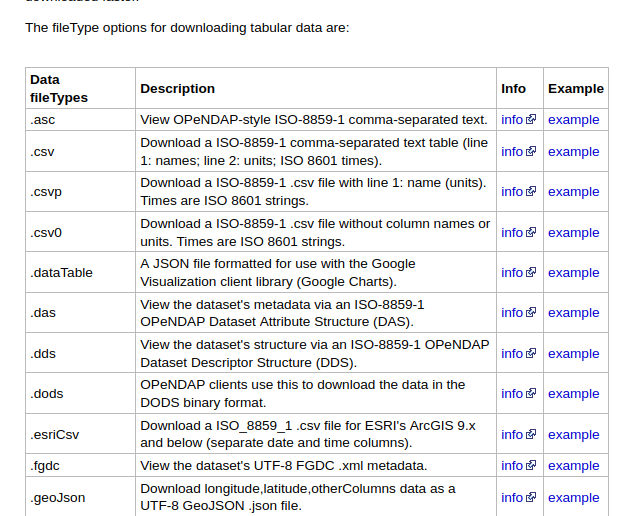  
--> there are many download formats available, o.a. many standard (open) formats (e.g. CSV, JSON, NetCDF, ...)

#### Discovery capabilities  
*Involves checking whether datasets are easily discoverable*  


Following server metadata endpoints were assessed via browser  
- `https://erddap.emso.eu/erddap/status.html`  
    - available  
    - contains information about the number of datasets, failing datasets, duplicates, users, etc.

- `https://erddap.emso.eu/erddap/version.html`  
    - not available  
    - *Unknown*

In [7]:
search_url = "https://erddap.emso.eu/erddap/search/index.csv?page=1&itemsPerPage=1000&searchFor=SST"
search_results = pd.read_csv(search_url)
search_results.head()

,griddap,Subset,tabledap,Make A Graph,wms,files,Title,Summary,FGDC,ISO 19115,Info,Background Info,RSS,Email,Institution,Dataset ID
0,https://erddap.emso.eu/erddap/griddap/OS_ESTOC...,NaN,NaN,https://erddap.emso.eu/erddap/griddap/OS_ESTOC...,NaN,NaN,"dm ctd-do-flntu, OS ESTOC 2014 D SST-PSAL-DOXI...",OceanSITES ESTOC in-situ data. The European St...,NaN,NaN,https://erddap.emso.eu/erddap/info/OS_ESTOC_20...,http://data.plocan.eu/thredds/PLOCAN-Observato...,https://erddap.emso.eu/erddap/rss/OS_ESTOC_201...,https://erddap.emso.eu/erddap/subscriptions/ad...,Oceanic Platform of the Canary Islands- PLOCAN,OS_ESTOC_2014_D_SST-PSAL-DOXI-CPHL-TURB_FixO3-...
1,https://erddap.emso.eu/erddap/griddap/OS_ESTOC...,NaN,NaN,https://erddap.emso.eu/erddap/griddap/OS_ESTOC...,NaN,NaN,"dm ctd-do-flntu, OS ESTOC 2015 D SST-PSAL-DOXI...",OceanSITES ESTOC in-situ data. The European St...,NaN,NaN,https://erddap.emso.eu/erddap/info/OS_ESTOC_20...,http://data.plocan.eu/thredds/PLOCAN-Observato...,https://erddap.emso.eu/erddap/rss/OS_ESTOC_201...,https://erddap.emso.eu/erddap/subscriptions/ad...,Oceanic Platform of the Canary Islands- PLOCAN,OS_ESTOC_2015_D_SST-PSAL-DOXI-CPHL-TURB_FixO3-...
2,https://erddap.emso.eu/erddap/griddap/OS_ESTOC...,NaN,NaN,https://erddap.emso.eu/erddap/griddap/OS_ESTOC...,NaN,NaN,"dm ctd-do-flntu, OS ESTOC 2015 D SST-PSAL-DOXI...",OceanSITES ESTOC in-situ data. The European St...,NaN,NaN,https://erddap.emso.eu/erddap/info/OS_ESTOC_20...,http://data.plocan.eu/thredds/PLOCAN-Observato...,https://erddap.emso.eu/erddap/rss/OS_ESTOC_201...,https://erddap.emso.eu/erddap/subscriptions/ad...,Oceanic Platform of the Canary Islands- PLOCAN,OS_ESTOC_2015_D_SST-PSAL-DOXI-DOXITEMP-CPHL_Fi...
3,https://erddap.emso.eu/erddap/griddap/OS_ESTOC...,NaN,NaN,https://erddap.emso.eu/erddap/griddap/OS_ESTOC...,NaN,NaN,"dm ctd-do-flntu, OS ESTOC 2016 D SST-PSAL-DOXI...",OceanSITES ESTOC in-situ data. The European St...,NaN,NaN,https://erddap.emso.eu/erddap/info/OS_ESTOC_20...,http://data.plocan.eu/thredds/PLOCAN-Observato...,https://erddap.emso.eu/erddap/rss/OS_ESTOC_201...,https://erddap.emso.eu/erddap/subscriptions/ad...,Oceanic Platform of the Canary Islands- PLOCAN,OS_ESTOC_2016_D_SST-PSAL-DOXI-DOXITEMP-CPHL-TU...
4,https://erddap.emso.eu/erddap/griddap/OS_ESTOC...,NaN,NaN,https://erddap.emso.eu/erddap/griddap/OS_ESTOC...,NaN,NaN,"dm ctd-do-flntu, OS ESTOC 2017 D SST-PSAL-DOXI...",OceanSITES ESTOC in-situ data. The European St...,NaN,NaN,https://erddap.emso.eu/erddap/info/OS_ESTOC_20...,http://data.plocan.eu/thredds/PLOCAN-Observato...,https://erddap.emso.eu/erddap/rss/OS_ESTOC_201...,https://erddap.emso.eu/erddap/subscriptions/ad...,Oceanic Platform of the Canary Islands- PLOCAN,OS_ESTOC_2017_D_SST-PSAL-DOXI-DOXITEMP-CPHL-TU...


Findings:

Protocol support:
- OPeNDAP-specific URL pattern show that ERDDAP service supports OPeNDAP protocol, which is an open standard for accessing a,d subsetting datasets over HTTP. 
- content negotiation not actually supported ?
- MIME TYPE should be application/x-netcdf ? or others, OPeNDAP responses often include MIME TYPES like 'application/opendap-das', 'application/opendap-dds' or 'application/octet-stream (for .dods)'

Data format compatibility 
- many standard formats are supported 

Discovery capabilities
- ease of discovering datasets (appears to be the case - not fully aware/capable of all ERDDAP keywords and constraints that can be used)  
- requires knowledge on interaction with ERDDAP servers   
- documentation available  

### Semantic interoperability

#### Presence and richness of metadata
*Involves checking availability and completeness of descriptive metadata, global metadata presence and if standard metadata fields are populated (e.g., `title`, `summary`, `institution`, `keywords`)*  


In [ ]:
#TO-DO

#### Use of standard vocabularies  
*Involves checking whether terms/properties follow standard vocabularies (e.g., NERC, CF, GCMD)*  

In [ ]:
# code that uses all_dataset_metadata and searches for use of standard vocabularies, 
# ontologies, standard identifiers (ROR-ID, ORCID, DOI, etc.) ....

all_dataset_metadata = pd.read_csv("files_emso_erddap/all_dataset_metadata.csv")
all_dataset_metadata

# !columns 'Attribute Name' and 'Value' of interest...

,Row Type,Variable Name,Attribute Name,Data Type,Value,DatasetID
0,attribute,NC_GLOBAL,cdm_data_type,String,Other,allDatasets
1,attribute,NC_GLOBAL,Conventions,String,"COARDS, CF-1.6, ACDD-1.3",allDatasets
2,attribute,NC_GLOBAL,creator_email,String,nobody@example.com,allDatasets
3,attribute,NC_GLOBAL,creator_name,String,Axiom Docker Install,allDatasets
4,attribute,NC_GLOBAL,creator_url,String,https://erddap.emso.eu/erddap,allDatasets
...,...,...,...,...,...,...
116004,attribute,depth_QC,actual_range,byte,"7, 7",EMSO_OBSEA_AWAC_waves_full
116005,attribute,depth_QC,conventions,String,OceanSITES QC Flags,EMSO_OBSEA_AWAC_waves_full
116006,attribute,depth_QC,flag_meanings,String,unknown;good_data;probably_good_data;potential...,EMSO_OBSEA_AWAC_waves_full
116007,attribute,depth_QC,flag_values,String,0;1;2;3;4;7;8;9,EMSO_OBSEA_AWAC_waves_full


In [ ]:
# Data Access Service
DATASET_ID = "EMSO_OBSEA_Buoy_Airmar_150WX_30min"
DAS_URL = f"{endpoint}/tabledap/{DATASET_ID}.das"
print("DAS URL", DAS_URL)
das_text = requests.get(DAS_URL).text
print(das_text)

In [ ]:
# Data Access Service
DATASET_ID = "EMSO_OBSEA_CTD_30min"
DAS_URL = f"{endpoint}/tabledap/{DATASET_ID}.das"
print("DAS URL", DAS_URL)
das_text = requests.get(DAS_URL).text
print(das_text)

#### Data annotation completeness 
*Involves checking accuracy and presence of descriptivle variables, e.g. whether they have `long_name`, `units`, `standard_name`, `coverage_content_type`*

In [ ]:
#to-do

Findings:
Presence of metadata fields  
- ...  

Richness of metadata structure & fields  
- ...  

Standard vocabularies used  
- in some cases, use of urls (e.g. for creator or OrcIDs)  
- use of URLs of known, standard licenses 
- opportunity for more use of persistent identifiers (e.g. station codes, ROR-id for institutes, ...)

Variable-level metadata
- ...  


# OLD stuff:

In [ ]:
## THIS CODE SHOULD BE APDAPED TO DO THE SAME BUT USES all_dataset_metadata.csv AS INPUT & BE MOVED TO SEMANTIC INTEROPERABILITY PART

import requests
import re
from pprint import pprint

# === CONFIGURATION ===
BASE_URL = "https://erddap.emso.eu/erddap"
DATASET_ID = "EMSO_OBSEA_Buoy_Airmar_150WX_30min"
DAS_URL = f"{BASE_URL}/tabledap/{DATASET_ID}.das"
INFO_URL = f"{BASE_URL}/info/{DATASET_ID}/index.json"

# === LOAD METADATA ===
das_text = requests.get(DAS_URL).text
info_json = requests.get(INFO_URL).json()

# === GLOBAL METADATA FIELDS ===
print("\n📌 Global Metadata Presence:\n")
required_fields = [
    "title", "summary", "institution", "keywords",
    "history", "source", "references", "license", "comment"
]
for field in required_fields:
    print(f"{'✅' if field in das_text else '❌'} {field}")

# === VARIABLE-LEVEL METADATA CHECK ===
print("\n📌 Variable Metadata Completeness:\n")
variable_blocks = re.findall(r'Attributes\s+{\s+(\w+).*?}', das_text, re.DOTALL)
complete_vars = 0
variable_metadata = []

for var in variable_blocks:
    block = re.search(rf'Attributes\s+{{\s+{var}(.*?)}}', das_text, re.DOTALL)
    if block:
        btext = block.group(1)
        has_long_name = "long_name" in btext
        has_units = "units" in btext
        has_std_name = "standard_name" in btext
        if has_long_name and has_units and has_std_name:
            complete_vars += 1
        variable_metadata.append({
            "variable": var,
            "long_name": has_long_name,
            "units": has_units,
            "standard_name": has_std_name
        })

print(f"✅ {complete_vars}/{len(variable_blocks)} variables have full metadata (long_name, units, standard_name)")
# Optional: pprint(variable_metadata)

# === VOCABULARY URIs ===
print("\n📌 Presence of Vocabulary URIs:\n")
uris = re.findall(r'(http[s]?://[^\s"]+)', das_text)
#drop duplicates
uris = list(set(uris))
#vocab_uris = [uri for uri in uris if "vocab" in uri or "cf" in uri or "nerc" in uri]
if uris:
    print(f"✅ Found {len(uris)} URI(s) referencing vocabularies:")
    for u in uris:
        print(f"  - {u}")
else:
    print("❌ No known vocabulary URIs found.")

# === MULTIFORMAT METADATA EXPOSURE ===
print("\n📌 Metadata Format Availability:\n")
format_urls = {
    "HTML": f"{BASE_URL}/tabledap/{DATASET_ID}.html",
    "DAS": DAS_URL,
    "DDS": f"{BASE_URL}/tabledap/{DATASET_ID}.dds",
    "JSON (info)": INFO_URL,
    "NCHeader": f"{BASE_URL}/tabledap/{DATASET_ID}.ncHeader"
}

for fmt, url in format_urls.items():
    r = requests.head(url)
    print(f"{'✅' if r.status_code == 200 else '❌'} {fmt} - {url}")

# === LICENSE AND CITATION ===
print("\n📌 License and Citation:\n")
for field in ["license", "citation"]:
    pattern = re.search(rf"{field}\s+\"(.*?)\"", das_text)
    if pattern:
        print(f"✅ {field}: {pattern.group(1)}")
    else:
        print(f"❌ {field} missing")


Exploration of **data** from each dataset offered through the ERDDAP server, by accessing as pd.DataFrame  
(less efficient than accessing as ncCF)

In [ ]:
#list datasets

# Connect to server 
erddap = ERDDAP(server="https://erddap.emso.eu/erddap", protocol="tabledap")

summary_full_df = pd.DataFrame()
#first half (otherwise code takes too long to run)
for datasetID in e['datasetID'][:len(e) // 2]:
    print(f"Processing dataset: {datasetID}")
    
    try:
        # Set the dataset ID
        erddap.dataset_id = datasetID
        
        # Fetch data as a 2D dataframe with timeout handling
        dataset_df = erddap.to_pandas()
        
        # Process data        
        summ_df = data_frame(dataset_df, datasetID)
        summary_full_df = pd.concat([summary_full_df, summ_df])
        
    except Exception as e:
        print(f"There was an error for {datasetID}: {e}")

# write first half to csv file
summary_full_df.to_csv("files_emso_erddap/EMSO_ERDDAP_dataset_data_metadata.csv", index=False)
# view
summary_full_df
#Property ~ variables (attributes & dimensions not clear)

In [ ]:
#second half
for datasetID in EMSO_alldatasets_df['datasetID'][(len(EMSO_alldatasets_df) // 2):]:
    print(f"Processing dataset: {datasetID}")
    
    try:
        # Set the dataset ID
        erddap.dataset_id = datasetID
        
        # Fetch data as a 2D dataframe with timeout handling
        dataset_df = erddap.to_pandas()
        
        # Process data        
        summ_df = data_frame(dataset_df, datasetID)
        summary_full_df = pd.concat([summary_full_df, summ_df], ignore_index=True)
        #overwrite each time, try to get info from as much datasets as possible before error
        summary_full_df.to_csv("files_emso_erddap/EMSO_ERDDAP_dataset_data_metadata2.csv", index=False)
    except Exception as e:
        print(f"There was an error for {datasetID}: {e}")


summary_full_df.to_csv("files_emso_erddap/EMSO_ERDDAP_dataset_data_metadata2.csv", index=False)
summary_full_df
#note: doesn't list netCDF attributes

Exploring CF Conventions

In [ ]:
# CF conventions
url = "https://erddap.emso.eu/erddap/tabledap/EMSO_OBSEA_CTD_30min.das"
response = requests.get(url)
print(json.load(response))

TODO: look at CFConventions 
--> https://erddap.emso.eu/erddap/tabledap/EMSO_OBSEA_CTD_30min.das 
--> ERDDAP = highly standized if links to BODC are present
--> access metadata to check this 

document way to get info from netCDF & analyse & compare that information (from both ERDDAP server and e.g. file server)

--> this should also be combined with SPARQL results ~ document steps needed to combine (in the SPARQL endpoints)

double check dimensions of EMSO!

https://data.icos-cp.eu/portal/#%7B%22route%22%3A%22preview%22%2C%22preview%22%3A%5B%22JAULaQy78I_n_3Zbq4DAT0fF%22%5D%2C%22yAxis%22%3A%22Temp%20%5BdegC%5D%22%7D --> should also be findable in EMSO data (~ shuold be the same)

format of the timestamp (ISO8601) ~ does this differ between data?

which coordinate system is used with long/lat?